In [31]:
# configure project root
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.env import PDPTWEnv
from src.policy import PDPTWAttentionPolicy
from src.generator import SFGenerator
from src.render import render
from src.or_tools import darp_solver as solver

import torch
import matplotlib.pyplot as plt

# Load from checkpoint

In [15]:
ckpt_path = str(PROJECT_ROOT) + "/checkpoints/Jan1401/latest.pt"

device = torch.device('cpu')

policy = PDPTWAttentionPolicy().to(device)
ckpt = torch.load(ckpt_path, map_location=device)

policy.load_state_dict(ckpt["policy_state_dict"])
policy.eval()

PDPTWAttentionPolicy(
  (init_embedding): PDPTWInitEmbedding(
    (project): Linear(in_features=34, out_features=128, bias=True)
  )
  (encoder): GraphAttentionNetwork(
    (layers): ModuleList(
      (0-2): 3 x MultiHeadAttentionLayer(
        (attn): MultiHeadAttention(
          (Wqkv): Linear(in_features=128, out_features=384, bias=True)
          (out_proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (norm1): Normalization(
          (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (ffn): MLP(
          (net): Sequential(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): ReLU()
            (2): Linear(in_features=512, out_features=128, bias=True)
          )
        )
        (norm2): Normalization(
          (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
  )
  (context_embedding): PDPTWContextE

# Evaluate on Env

In [21]:
csv_path = Path(str(PROJECT_ROOT) + "/src/traveler_trip_types_res_7.csv")
ttm_path = Path(str(PROJECT_ROOT) + "/src/travel_time_matrix_res_7.csv")

generator = SFGenerator(csv_path=csv_path, travel_time_matrix_path=ttm_path)
env = PDPTWEnv(generator=generator)

batch_size = 16
batch = generator(batch_size=[batch_size]).to(device)
state = env.reset(batch)

with torch.inference_mode():
    out = policy(state, env, phase="test", decode_type="greedy", max_steps=300)

actions = out["actions"]
print(f"actions shape for {batch_size} environments: {actions.shape}")

actions shape for 16 environments: torch.Size([16, 78])


Web Mercator basemap failed: The EPSG code is unknown. PROJ: internal_proj_create_from_database: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_create_from_database: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Route:  [[0, 39, 17, 40, 18, 1, 2, 33, 57, 34, 58, 0, 45, 46, 35, 13, 36, 14, 55, 56, 0, 11, 19, 20, 12, 41, 42, 43, 44, 51, 52, 0, 3, 4, 21, 22, 9, 23, 10, 24, 47, 49, 50, 48, 29, 30, 25, 26, 31, 5, 6, 32, 7, 8, 27, 28, 37, 38, 0, 53, 54, 59, 60, 15, 16, 0]]


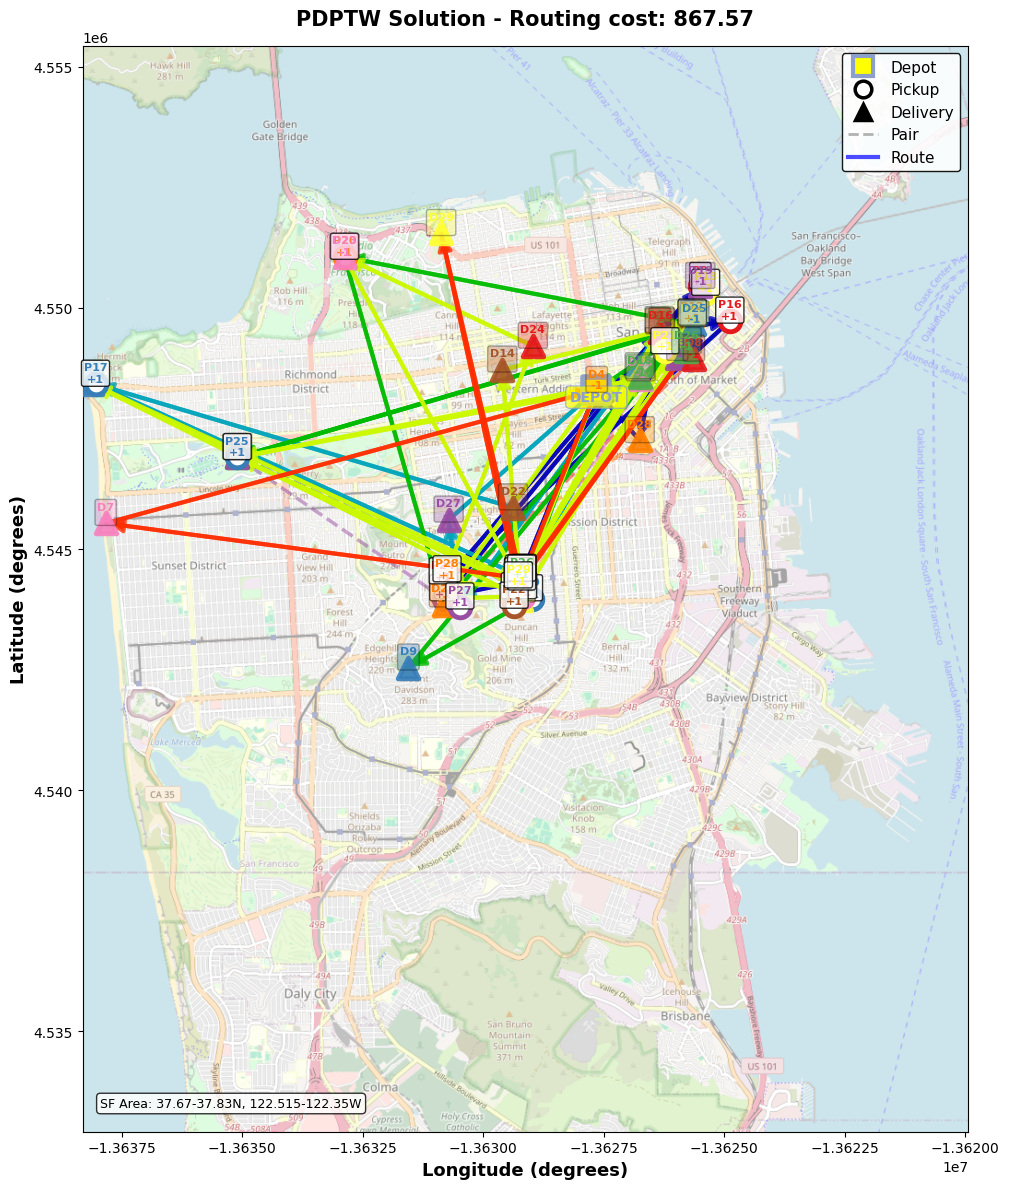

In [30]:

batch = generator(batch_size=[1]).to(device)
state = env.reset(batch)

with torch.inference_mode():
    out = policy(state, env, phase="test", decode_type="greedy", max_steps=300)

actions = out["actions"]  # shape [1, seq_len]
reward = env.get_reward(batch, actions)
routing_cost = (-reward[0]).item()

effective_route = env._build_effective_routes(actions)
print("Route: ", effective_route)

# render
fig, ax = plt.subplots(figsize=(14, 12))
render(batch, actions=actions, ax=ax)
ax.set_title(f"PDPTW Solution - Routing cost: {routing_cost:.2f}", fontsize=15, weight="bold", pad=15)
plt.show()

In [34]:
or_out = solver(state, time_limit_seconds=1)
import pprint
pprint.pprint(or_out)

{'routes': [[21, 22, 13, 14, 43, 33, 44, 34, 55, 56, 15, 16, 31, 5, 6, 32],
            [17,
             39,
             18,
             40,
             45,
             46,
             53,
             54,
             1,
             2,
             47,
             49,
             59,
             60,
             48,
             50,
             29,
             51,
             30,
             52,
             25,
             26,
             7,
             8,
             27,
             28,
             37,
             38],
            [19, 11, 20, 12, 3, 4, 35, 41, 36, 42, 9, 23, 24, 57, 58, 10]],
 'total_time': 599.4999957084656,
 'vehicles_used': 3}
